In [1]:
library(data.table) #to read gz file
library(tidyverse)
library(patchwork)
library(scSeqComm)
library(doRNG)
library(community)
# library(scSeqCommEdited)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  ma

In [2]:
data(LR_database)
community_db <- LR_database

In [3]:
write_csv(community_db, "/work/project/ladcol_011/MariaWF/cell2cell/community_db.csv")

In [4]:
.libPaths()

[1] "/work/project/ladcol_011/conda_path/miniconda3/envs/r44/lib/R/library"

In [5]:
input_dir <- "/work/project/ladcol_011/MariaWF/community-paper/src/data_preprocessing/Lasry/2.filtering/outs/"
output_dir <- "outs/"

In [6]:
# counts <- fread(paste0(input_dir,"counts_lognorm.csv.gz"), header = TRUE)
# counts <- as.data.frame(counts)
# rownames(counts) <- counts$gene_symbol
# counts <- counts[,-1]
# # print(str(counts))

In [7]:
anno_cells <- read.table(paste0(input_dir,"anno_cells_norm.txt")
                         ,sep = "\t"
                         # ,row.names = 1
                         ,header = TRUE
                         )
# print(str(anno_cells))

In [8]:
anno_cells = anno_cells %>% 
  rename(
    Cell_ID = cell_ID,
    Sample_ID = sample_ID,
    Cluster_ID = cell_type,
    Condition_ID = health_status
    )

In [9]:
counts <- read_rds("/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/prepare_data/run_community//outs/counts_pct_filtered.rds")

In [10]:
colnames(counts) <- anno_cells$Cell_ID
rownames(anno_cells) <- anno_cells$Cell_ID

In [11]:
counts_sparse <- Matrix::Matrix(as.matrix(counts), sparse = TRUE)

colnames(counts_sparse) <- anno_cells$Cell_ID
rownames(anno_cells) <- anno_cells$Cell_ID

In [12]:
class(counts_sparse)

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

In [13]:
class(counts)

[1] "data.frame"

In [14]:
counts_m = as.matrix(counts)

colnames(counts_m) <- anno_cells$Cell_ID
rownames(anno_cells) <- anno_cells$Cell_ID

In [15]:
anno_cells$group <- paste(anno_cells$Sample_ID, anno_cells$Cluster_ID, sep = "_")

In [16]:
# anno_cells <- anno_cells[match(colnames(counts), anno_cells$Cell_ID), ]

In [17]:
# for(g in unique(anno_cells$group)) {
#   cols <- which(anno_cells$group == g)
#   submat <- counts[, cols, drop = FALSE]
  
#   n_cells <- length(cols)
#   prop_expressed <- rowSums(submat > 0) / n_cells
  
#   low_genes <- which(prop_expressed < 0.1)
#   if(length(low_genes) > 0) {
#     counts[low_genes, cols] <- 0
#   }
# }

In [18]:
# table(anno_cells$group)

In [19]:
# counts_sparse <- Matrix::Matrix(as.matrix(counts), sparse = TRUE)

# colnames(counts_sparse) <- anno_cells$Cell_ID
# rownames(anno_cells) <- anno_cells$Cell_ID

In [20]:
data(TF_TG_TRRUSTv2_HTRIdb_RegNetwork_High)
TF_TG_db <- TF_TG_TRRUSTv2_HTRIdb_RegNetwork_High

data(TF_PPR_KEGG_human)
TF_PPR <- TF_PPR_KEGG_human

In [21]:
data(LR_database)
community_db <- LR_database

community_db <- community_db[, c("True_LR", "Ligand", "Receptor")]

community_db <- rename(community_db, c('ligand' = 'Ligand', "receptor" = "Receptor"))

head(community_db)

,True_LR,ligand,receptor
,<lgl>,<chr>,<chr>
1,TRUE,S100A10,TRPV6
2,TRUE,JAG2,NOTCH1
3,TRUE,DLL1,NOTCH1
4,TRUE,IGF1,IGF1R
5,TRUE,JAG1,NOTCH1
6,TRUE,WNT5A,FZD2


In [22]:
cond_names = c("AML", "healthy")

# define alternative hypothesis for differential intercellular signaling
alternative_inter = "two.sided"

# define sign of DE
only.pos = F

# define the number of cores to use
num_core <- 4

In [23]:
ConnectomeDB <- LR_pairs_ConnectomeDB_2020

In [24]:
scSeqCommDiff_res <- scSeqComm_differential(gene_expr = counts_m,
                                            cell_metadata =  anno_cells, 
                                            scenario = "multi-sample",
                                            cond_names = cond_names,
                                            LR_pairs_DB = ConnectomeDB,
                                            alternative_inter = alternative_inter,
                                            TF_reg_DB = TF_TG_db,
                                            R_TF_association = TF_PPR,
                                            only.pos = only.pos,
                                            N_cores = 10, intra_signaling=FALSE, padj_method = "fdr", min_cells = 30,
                                            count_thr = 1)

Check input data...

**** scRNA-seq gene expression matrix having 

 - 15770 genes

 - 46702 cells

Working with ... matrix

**** cell metadata having 

 - 46702 cells

 - 8 cell groups/clusters (  Mono  Gran  T  NK  B  HSPC  Ery  DC  )

 - 2 experimental conditions (  AML  healthy  )

 - 13 samples


Analyzing intercellular communications...


...for experimental group: AML



9.626 sec elapsed
1.031 sec elapsed
3.201 sec elapsed



...for experimental group: healthy



10.899 sec elapsed
1.133 sec elapsed
3.708 sec elapsed



Analyzing differential intercellular signaling...

testing AML vs healthy


 ... using intercellular scoring scheme: S_inter

using 10 cores with doParallelMC



17.985 sec elapsed


In [25]:
diff_df = scSeqCommDiff_res$differential_comm

In [26]:
min(diff_df[!is.na(diff_df$pvalue_adj_S_inter),]$pvalue_adj_S_inter)

[1] 1

In [27]:
min(diff_df[!is.na(diff_df$pvalue_adj_S_inter),]$pvalue_S_inter)

[1] 0.001939728

In [28]:
length(diff_df[!is.na(diff_df$pvalue_adj_S_inter),]$pvalue_S_inter)

[1] 6673

ERROR: Error: object 'diff_df' not found


In [30]:
na_df <- diff_df[!is.na(diff_df$pvalue_adj_S_inter),]

In [31]:
dim(na_df[na_df$pvalue_S_inter < 0.05,])

[1] 849  14

In [32]:
significant = na_df[na_df$pvalue_S_inter < 0.05,]
significant$interaction_ID <- paste0(significant$cluster_L, ":", significant$ligand, "_", significant$cluster_R, ":", significant$receptor)

In [33]:
community_input_dir <- "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/prepare_data/run_community/outs/"

suppressWarnings(load(paste0(community_input_dir,"community_interactions.RData")))

idx_sign <- !is.na(community_interactions$anno_interactions$sign) & community_interactions$anno_interactions$sign

community_set1 <- community_interactions$anno_interactions[idx_sign,]

In [34]:
dim(significant[significant$interaction_ID %in% community_set1$interaction_ID,])

[1] 22 15

In [35]:
na_df

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
181,LGALS1,CD69,LGALS1 - CD69,B,B,B --> B,0.0870565212,1.118490e-09,26.213896391,4.352826e-02,0.02680913,0.63529277,4-M,0.3648623
212,LGALS1,ITGB1,LGALS1 - ITGB1,B,B,B --> B,0.0157843888,2.569283e-11,29.194485513,7.892194e-03,0.05247016,0.62380868,4-M,0.3671097
213,LGALS1,PTPRC,LGALS1 - PTPRC,B,B,B --> B,0.2295051154,1.118490e-09,27.612398424,1.147526e-01,0.02680913,0.76265376,4-M,0.3648623
219,TGFB1,CXCR4,TGFB1 - CXCR4,B,B,B --> B,0.1457735744,2.512034e-08,22.468369989,7.288680e-02,0.03831876,0.48789646,3-S,0.3648623
327,ARF6,SMAP1,ARF6 - SMAP1,B,B,B --> B,0.0003114029,1.517630e-05,4.358890461,1.632896e-04,1.00000000,0.48052804,3-S,1.0000000
474,HLA-A,APLP2,HLA-A - APLP2,B,B,B --> B,0.0311160289,9.507985e-03,1.710446449,2.031201e-02,0.72098486,0.41364186,3-S,0.9033293
475,CD99,CD81,CD99 - CD81,B,B,B --> B,0.0776829424,3.118004e-10,27.892399770,3.884147e-02,0.02680913,0.70454107,4-M,0.3648623
561,FAM3C,LAMP1,FAM3C - LAMP1,B,B,B --> B,0.0001229563,3.275981e-08,11.873930840,6.149452e-05,0.02660030,0.73462584,4-M,0.3648623
596,LTB,CD40,LTB - CD40,B,B,B --> B,0.1002534992,1.297036e-01,-0.371566449,1.149786e-01,0.83032426,-0.09721634,2-VS,0.9399073


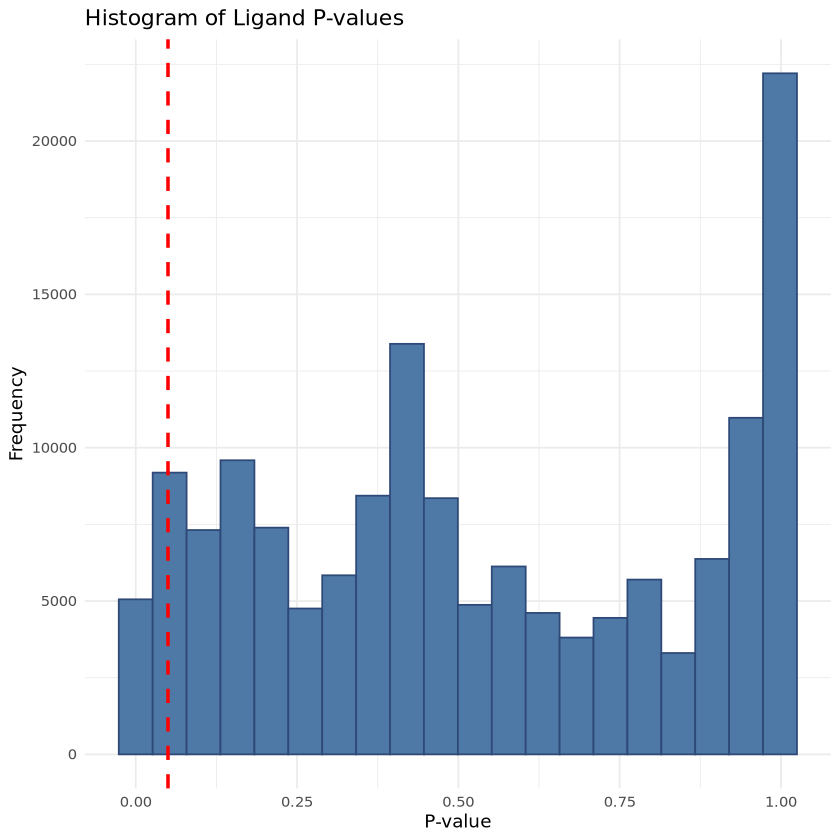

In [30]:
ggplot(na_df, aes(x = pvalue_S_inter)) +
  geom_histogram(bins = 20, fill = "#4e79a7", color = "#2e4977") +
  geom_vline(xintercept = 0.05, color = "red", linetype = "dashed", linewidth = 1) +
  labs(title = "Histogram of Ligand P-values", x = "P-value", y = "Frequency") +
  theme_minimal()

In [39]:
stats::p.adjust(diff_df[!is.na(diff_df$pvalue_adj_S_inter),]$pvalue_S_inter, method = "bonferroni")

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  [75] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [112] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [149] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [186] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [223] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [260] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [297] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [334] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [371] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [408] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [445] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [482] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [519] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [556] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [593] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [630] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [667] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [704] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [741] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [778] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [815] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [852] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [889] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [926] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [963] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1000] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1037] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1074] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1111] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1148] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1185] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1222] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1259] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1296] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1333] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1370] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1407] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1444] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1481] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1518] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1555] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1592] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1629] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1666] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1703] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1740] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1777] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1814] 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [32]:
dim(diff_df)

[1] 151744     14

In [33]:
dim(diff_df[is.na(diff_df$pvalue_adj_S_inter),])

[1]  0 14

In [34]:
dim(diff_df[is.na(diff_df$pvalue_adj_S_inter),])

[1]  0 14

In [35]:
head(diff_df)

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,JAG2,NOTCH1,JAG2 - NOTCH1,B,B,B --> B,0.0003804091,0.000000e+00,Inf,1.902046e-04,0.2115897,0.5989926,4-M,0.9156919
2,DLL1,NOTCH1,DLL1 - NOTCH1,B,B,B --> B,0.0198776622,4.426785e-03,2.166817,1.215222e-02,0.3394849,0.5091927,4-M,0.9156919
3,IGF1,IGF1R,IGF1 - IGF1R,B,B,B --> B,0.0002423497,4.054206e-03,-4.064257,2.148278e-03,0.1282501,-0.8406963,5-L,0.8796804
4,JAG1,NOTCH1,JAG1 - NOTCH1,B,B,B --> B,0.0002881143,4.424186e-03,-3.940699,2.356150e-03,0.8069804,-0.5257934,4-M,1.0000000
5,CCL3L1,CCR5,CCL3L1 - CCR5,B,B,B --> B,0.0000000000,6.309260e-05,-Inf,3.154630e-05,0.1398541,-0.5632838,4-M,0.8796804
6,TNFSF10,TNFRSF10C,TNFSF10 - TNFRSF10C,B,B,B --> B,0.0000000000,3.558835e-24,-Inf,1.779418e-24,0.3545395,-0.5632838,4-M,0.9156919


In [36]:
head(scSeqCommDiff_res$intercellular_signaling$AML$comm_results)

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,L_score_S_lr,R_score_S_lr,S_inter,mean.count_L,mean.count_R,mean.expression,mean.product
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,JAG2,NOTCH1,JAG2 - NOTCH1,B,B,B --> B,2.272375e-19,1.182670e-10,2.272375e-19,0.002657638,0.03476401,0.002657638,9.239015e-05
2,DLL1,NOTCH1,DLL1 - NOTCH1,B,B,B --> B,2.132876e-16,1.182670e-10,2.132876e-16,0.012486577,0.03476401,0.012486577,4.340835e-04
3,IGF1,IGF1R,IGF1 - IGF1R,B,B,B --> B,3.422398e-08,5.659095e-13,5.659095e-13,0.046432665,0.02511070,0.046432665,1.165957e-03
4,JAG1,NOTCH1,JAG1 - NOTCH1,B,B,B --> B,1.187541e-17,1.182670e-10,1.187541e-17,0.008229816,0.03476401,0.008229816,2.861014e-04
5,CCL3L1,CCR5,CCL3L1 - CCR5,B,B,B --> B,3.768682e-16,0.000000e+00,0.000000e+00,0.013346343,0.00000000,0.013346343,0.000000e+00
6,TNFSF10,TNFRSF10C,TNFSF10 - TNFRSF10C,B,B,B --> B,3.548493e-13,0.000000e+00,0.000000e+00,0.024315164,0.00000000,0.024315164,0.000000e+00


In [66]:
diff_sig = subset(diff_df, pvalue_S_inter < 0.05)

In [67]:
head(diff_sig)

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
181,LGALS1,CD69,LGALS1 - CD69,B,B,B --> B,0.0870565212,1.118490e-09,26.213896,4.352826e-02,0.02680913,0.6352928,4-M,0.3648623,B:LGALS1_B:CD69
213,LGALS1,PTPRC,LGALS1 - PTPRC,B,B,B --> B,0.2295051154,1.118490e-09,27.612398,1.147526e-01,0.02680913,0.7626538,4-M,0.3648623,B:LGALS1_B:PTPRC
219,TGFB1,CXCR4,TGFB1 - CXCR4,B,B,B --> B,0.1457735744,2.512034e-08,22.468370,7.288680e-02,0.03831876,0.4878965,3-S,0.3648623,B:TGFB1_B:CXCR4
475,CD99,CD81,CD99 - CD81,B,B,B --> B,0.0776829424,3.118004e-10,27.892400,3.884147e-02,0.02680913,0.7045411,4-M,0.3648623,B:CD99_B:CD81
561,FAM3C,LAMP1,FAM3C - LAMP1,B,B,B --> B,0.0001229563,3.275981e-08,11.873931,6.149452e-05,0.02660030,0.7346258,4-M,0.3648623,B:FAM3C_B:LAMP1
1078,MIF,CD44,MIF - CD44,B,B,B --> B,0.8039447436,2.972957e-01,1.435198,5.506202e-01,0.02680913,1.3919306,6-VL,0.3648623,B:MIF_B:CD44


In [68]:
dim(diff_sig)

[1] 849  15

In [69]:
dim(diff_sig[diff_sig$logFC_S_inter > 1,])

[1] 568  15

In [70]:
dim(diff_sig[diff_sig$logFC_S_inter < 1,])

[1] 281  15

In [71]:
diff_sig$direction <- ifelse(diff_sig$logFC_S_inter > 1, "up", "down")

In [72]:
diff_sig$interaction_ID <- paste0(diff_sig$cluster_L, ":", diff_sig$ligand, "_", diff_sig$cluster_R, ":", diff_sig$receptor)

In [73]:
table(diff_sig$direction)


down   up 
 281  568 

In [74]:
aml_dist <- scSeqCommDiff_res$intercellular_signaling$AML$distribution_results
healthy_dist <- scSeqCommDiff_res$intercellular_signaling$healthy$distribution_results

In [75]:
aml_dist$interaction_ID <- paste0(aml_dist$cluster_L, ":", aml_dist$ligand, "_", aml_dist$cluster_R, ":", aml_dist$receptor)
healthy_dist$interaction_ID <- paste0(healthy_dist$cluster_L, ":", healthy_dist$ligand, "_", healthy_dist$cluster_R, ":", healthy_dist$receptor)

In [76]:
length(aml_dist)

[1] 14

In [77]:
# scSeqCommDiff_res$intercellular_signaling$AML$comm_results

In [78]:
diff_df$interaction_ID <- paste0(diff_df$cluster_L, ":", diff_df$ligand, "_", diff_df$cluster_R, ":", diff_df$receptor)
diff_df[diff_df$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
112987,HMGB1,CXCR4,HMGB1 - CXCR4,Mono,T,Mono --> T,0.9999933,0.9985743,0.002048557,0.9992838,0.328424,0.5971354,4-M,0.6786764,Mono:HMGB1_T:CXCR4


In [79]:
x1 = c(1,1,1,1,1,1,0.9999528)

In [ ]:
x2 = c(1, 0.99, 099, )

In [ ]:
pval <- wilcox.test(x1,y=x2,exact=FALSE, alternative = alternative)

In [50]:
aml_dist[aml_dist$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_1,S_inter_2,S_inter_3,S_inter_4,S_inter_5,S_inter_6,S_inter_7,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
112987,HMGB1,CXCR4,HMGB1 - CXCR4,Mono,T,Mono --> T,1,1,1,1,0.9999528,1,1,Mono:HMGB1_T:CXCR4


In [51]:
healthy_dist[healthy_dist$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_1,S_inter_2,S_inter_3,S_inter_4,S_inter_5,S_inter_6,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
112987,HMGB1,CXCR4,HMGB1 - CXCR4,Mono,T,Mono --> T,1,0.9995668,0.9999879,0.9918912,1,1,Mono:HMGB1_T:CXCR4


In [80]:
head(anno_cells$group)

[1] "AML-0024_Mono" "AML-0024_Mono" "AML-0024_Mono" "AML-0024_Mono"
[5] "AML-0024_Mono" "AML-0024_Mono"

In [81]:
anno_cells$group <- paste(anno_cells$Sample_ID, anno_cells$Cluster_ID, sep = "_")

In [82]:
anno_cells <- anno_cells[match(colnames(counts), anno_cells$Cell_ID), ]

In [55]:
# cols <- which(anno_cells$group == "AML-0024_Mono")
# aml_mono <- counts[, cols, drop = FALSE]
# cols <- which(anno_cells$group == "AML-0024_T")
# aml_t <- counts[, cols, drop = FALSE]

In [56]:
# dim(aml_mono)

In [57]:
# dim(aml_t)

In [58]:
# typeof(aml_mono)

In [59]:
# BigBootstrapSparse <- function(M, colIndex, H0_genes, ligands, receptors) {
#     .Call('_scSeqComm_BigBootstrapSparse', PACKAGE = 'scSeqComm', M, colIndex, H0_genes, ligands, receptors)
# }


In [60]:
# aml_mono <- Matrix::Matrix(as.matrix(aml_mono), sparse = TRUE)
# aml_t <- Matrix::Matrix(as.matrix(aml_t), sparse = TRUE)

In [61]:
# head(rownames(aml_mono))

In [62]:
# res <- BigBootstrapSparse(M = aml_mono, colIndex = colnames(aml_mono), H0_genes = rownames(aml_mono), ligands = c("HMGB1"),  receptors = c("CXCR4"))

In [63]:
# lig_avg_expr = Matrix::rowMeans(aml_mono["HMGB1", ])
# rec_avg_expr = Matrix::rowMeans(aml_t["CXCR4", ])

In [64]:
# res <- list()

# res$lig_avg_expr <- lig_avg_expr
# res$rec_avg_expr <-rec_avg_expr


In [65]:
# aml_mono_matrix = as.matrix(unlist(aml_mono))

In [66]:
# aml_mono_matrix

In [67]:
# res$H0_sd <- sd(aml_mono) / sqrt(length(aml_mono))

In [68]:
# H0_mean <- Matrix::mean(aml_mono)
# H0_sd <- sd(aml_mono) / sqrt(length(aml_mono))
# score_L <- pnorm(lig_avg_expr, mean = H0_mean, sd = H0_sd)

In [83]:
diff_df[diff_df$interaction_ID == "Mono:CD14_Gran:PLXND1",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
103964,CD14,PLXND1,CD14 - PLXND1,Mono,Gran,Mono --> Gran,0.07212007,6.319259e-06,13.47836,0.03606319,NaN,NaN,NaN,NaN,Mono:CD14_Gran:PLXND1


In [84]:
aml_dist[aml_dist$interaction_ID == "Mono:HMGB1_Gran:CXCR4",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_1,S_inter_2,S_inter_3,S_inter_4,S_inter_5,S_inter_6,S_inter_7,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
103503,HMGB1,CXCR4,HMGB1 - CXCR4,Mono,Gran,Mono --> Gran,1,1,1,1,NA,0.9999975,0.6421121,Mono:HMGB1_Gran:CXCR4


In [61]:
healthy_dist[healthy_dist$interaction_ID == "Mono:HMGB1_Gran:CXCR4",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,S_inter_1,S_inter_2,S_inter_3,S_inter_4,S_inter_5,S_inter_6,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
103503,HMGB1,CXCR4,HMGB1 - CXCR4,Mono,Gran,Mono --> Gran,1,0.9417274,0.8351797,1,1,0.9599238,Mono:HMGB1_Gran:CXCR4


In [72]:
# x1 = c(0,0, 0.6249386, 0, NA, 0, 0.9975926)
# x2 = c(0.0339324,0.04592152, 0.2942978, 0.5696934, 0.9977729, 0.9998254)

In [73]:
# wilcox.test(x1,y=x2, alternative = "two.sided")

In [74]:
# mean(c(0,0.8705511,0,0.9495617,0.9012627,0,0.9816895))

In [55]:
aml_com = scSeqCommDiff_res$intercellular_signaling$AML$comm_results

In [56]:
aml_com$interaction_ID <- paste0(aml_com$cluster_L, ":", aml_com$ligand, "_", aml_com$cluster_R, ":", aml_com$receptor)

In [58]:
aml_com[aml_com$interaction_ID == "Mono:CD14_Gran:PLXND1",]

,ligand,receptor,LR_pair,cluster_L,cluster_R,interaction,L_score_S_lr,R_score_S_lr,S_inter,mean.count_L,mean.count_R,mean.expression,mean.product,interaction_ID
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
103964,CD14,PLXND1,CD14 - PLXND1,Mono,Gran,Mono --> Gran,1,9.997796e-33,9.997796e-33,1.650003,0.05798337,1.650003,0.09567275,Mono:CD14_Gran:PLXND1


In [78]:
unique(anno_cells$Sample_ID)

[1] "AML-0024"     "AML-0160"     "AML-0693"     "AML-1371"     "AML-2123"    
 [6] "AML-3133"     "AML-4340"     "healthy-1"    "healthy-2"    "healthy-3"   
[11] "healthy-4"    "healthy-4003" "healthy-5"

In [79]:
aml_dist <- aml_dist[c(7:length(aml_dist))]

In [80]:
healthy_dist <- healthy_dist[c(7:length(healthy_dist))]

In [81]:
colnames(healthy_dist) <- str_replace(colnames(healthy_dist), "S_inter", "healthy")

In [82]:
colnames(aml_dist) <- str_replace(colnames(aml_dist), "S_inter", "AML")

In [83]:
ids <- diff_sig$interaction_ID

aml_sub <- aml_dist[aml_dist$interaction_ID %in% ids, , drop=FALSE]
healthy_sub <- healthy_dist[healthy_dist$interaction_ID %in% ids, , drop=FALSE]

rownames(aml_sub) <- ids
rownames(healthy_sub) <- ids

In [84]:
head(ids)

[1] "B:GAS6_B:MERTK"   "B:LTA_B:TNFRSF14" "B:LTA_B:TNFRSF1B" "B:GAS6_B:TYRO3"  
[5] "B:TNF_B:TNFRSF21" "B:ASIP_B:ATRN"

In [85]:
aml_sub <- aml_sub[match(ids, rownames(aml_sub)), ]
healthy_sub <- healthy_sub[match(ids, rownames(healthy_sub)), ]

In [86]:
weight_mat <- cbind(aml_sub, healthy_sub)
rownames(weight_mat) <- ids

In [87]:
head(weight_mat)

,AML_1,AML_2,AML_3,AML_4,AML_5,AML_6,AML_7,interaction_ID,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,interaction_ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B:GAS6_B:MERTK,0.0000000,0.0000000,5.954193e-10,0.000000000,0.0000000,0.000000000,0.00000000,B:GAS6_B:MERTK,3.592641e-05,0.007875553,6.642645e-09,8.124245e-23,0.000000e+00,0.0005278951,B:GAS6_B:MERTK
B:LTA_B:TNFRSF14,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,B:LTA_B:TNFRSF14,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF14
B:LTA_B:TNFRSF1B,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,B:LTA_B:TNFRSF1B,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF1B
B:GAS6_B:TYRO3,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,B:GAS6_B:TYRO3,5.630645e-05,0.006292253,6.452323e-09,5.920724e-24,1.813069e-05,0.0007048456,B:GAS6_B:TYRO3
B:TNF_B:TNFRSF21,0.0000000,0.0000000,3.216296e-09,0.000000000,0.0000000,0.000000000,0.00000000,B:TNF_B:TNFRSF21,6.010160e-04,0.008860955,6.515376e-09,6.672071e-19,0.000000e+00,0.0006079496,B:TNF_B:TNFRSF21
B:ASIP_B:ATRN,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,B:ASIP_B:ATRN,0.000000e+00,0.000000000,1.774606e-08,1.714717e-23,2.229447e-05,0.0006030196,B:ASIP_B:ATRN


In [88]:
head(aml_sub)

,AML_1,AML_2,AML_3,AML_4,AML_5,AML_6,AML_7,interaction_ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B:GAS6_B:MERTK,0.0000000,0.0000000,5.954193e-10,0.000000000,0.0000000,0.000000000,0.00000000,B:GAS6_B:MERTK
B:LTA_B:TNFRSF14,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,B:LTA_B:TNFRSF14
B:LTA_B:TNFRSF1B,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,B:LTA_B:TNFRSF1B
B:GAS6_B:TYRO3,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,B:GAS6_B:TYRO3
B:TNF_B:TNFRSF21,0.0000000,0.0000000,3.216296e-09,0.000000000,0.0000000,0.000000000,0.00000000,B:TNF_B:TNFRSF21
B:ASIP_B:ATRN,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,B:ASIP_B:ATRN


In [89]:
head(healthy_sub)

,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,interaction_ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B:GAS6_B:MERTK,3.592641e-05,0.007875553,6.642645e-09,8.124245e-23,0.000000e+00,0.0005278951,B:GAS6_B:MERTK
B:LTA_B:TNFRSF14,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF14
B:LTA_B:TNFRSF1B,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF1B
B:GAS6_B:TYRO3,5.630645e-05,0.006292253,6.452323e-09,5.920724e-24,1.813069e-05,0.0007048456,B:GAS6_B:TYRO3
B:TNF_B:TNFRSF21,6.010160e-04,0.008860955,6.515376e-09,6.672071e-19,0.000000e+00,0.0006079496,B:TNF_B:TNFRSF21
B:ASIP_B:ATRN,0.000000e+00,0.000000000,1.774606e-08,1.714717e-23,2.229447e-05,0.0006030196,B:ASIP_B:ATRN


In [85]:
diff_sig <- diff_sig %>% rename(sender_gene = ligand, receiver_gene = receptor, sender_celltype = cluster_L, receiver_celltype = cluster_R)

In [91]:
scseqcom_interactions = list()
scseqcom_interactions$anno_interactions <- diff_sig
scseqcom_interactions$weights <- weight_mat

In [92]:
dim(diff_sig[!diff_sig$mean_S_inter > 0.5,])

[1] 8198   16

In [93]:
save(scseqcom_interactions, file="outs/scseqcom_interactions.RData")

In [94]:
"/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/"

[1] "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/"

In [62]:
community_input_dir <- "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/prepare_data/run_community/outs/"

suppressWarnings(load(paste0(community_input_dir,"community_interactions.RData")))

In [63]:
idx_down <- community_interactions$anno_interactions$log2FC_weights < 0
idx_up <- community_interactions$anno_interactions$log2FC_weights > 0

community_interactions$anno_interactions$direction <- NA
community_interactions$anno_interactions$direction[idx_down] <- "down"
community_interactions$anno_interactions$direction[idx_up] <- "up"
community_interactions$anno_interactions$direction[!idx_sign] <- "not significant"

In [64]:
dim(community_interactions$anno_interactions)

[1] 151744     53

In [86]:
anno = community_interactions$anno_interactions

diff_sig <- diff_sig %>%
  left_join(select(anno, interaction_ID, direction), 
            by = "interaction_ID") %>%
  rename(direction_anno = direction.y)

In [87]:
diff_sig <- diff_sig %>%
  rename(direction_scSeqCom = direction.x, 
         direction_community = direction_anno)

In [88]:
as.data.frame(table(diff_sig[c("direction_scSeqCom", "direction_community")]))

direction_scSeqCom,direction_community,Freq
<fct>,<fct>,<int>
down,down,19
up,down,3
down,not significant,262
up,not significant,565


In [131]:
as.data.frame(table(diff_sig[c("direction_scSeqCom", "direction_community")]))

direction_scSeqCom,direction_community,Freq
<fct>,<fct>,<int>
down,down,401
up,down,0
down,not significant,1136
up,not significant,641
down,up,1
up,up,6


In [102]:
# diff_sig[diff_sig$interaction_ID %in% community_interactions$anno_interactions$interaction_ID,]

In [103]:
idx_sign <- !is.na(community_interactions$anno_interactions$sign) & community_interactions$anno_interactions$sign

In [104]:
community_sign = community_interactions$anno_interactions[idx_sign,]

In [105]:
table(community_sign$direction)


down   up 
 726    9 

In [115]:
# diff_sig[!diff_sig$interaction_ID %in% community_sign$interaction_ID,]

In [117]:
community_interactions$anno_interactions[community_interactions$anno_interactions$interaction_ID %in% diff_sig$interaction_ID,]

,interaction_ID,ligand_gene_name,receptor_gene_name,sending_cell_type,receiving_cell_type,mean_e_s_l_control,mean_e_s_l_case,mean_e_r_r_control,mean_e_r_r_case,log2FC_rho_s,⋯,components_affected_r,sender_or_receiver_affected,direction_s,direction_r,direction_b,concordance_s,concordance_r,concordance_b,interaction_category,direction
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<chr>,<chr>
129,Mono:ANXA1_Mono:FPR1,ANXA1,FPR1,Mono,Mono,2.3816796,2.6246328,1.4372106,1.0659150,-0.4546995,⋯,phi,receiver,none,down,down,undefined,undefined,undefined,undefined,not significant
175,Mono:HLA-F_Mono:LILRB1,HLA-F,LILRB1,Mono,Mono,1.3635246,1.0066553,1.3279583,1.0613923,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,undefined,not significant
228,Mono:NAMPT_Mono:ADORA2A,NAMPT,ADORA2A,Mono,Mono,2.2295231,2.4452055,0.0000000,0.5948626,-0.4546995,⋯,phi p,receiver,none,up,up,undefined,concordant,concordant,concordant_increase,not significant
278,Mono:THBS1_Mono:ITGA4,THBS1,ITGA4,Mono,Mono,1.8617734,0.8889501,1.4022344,1.2759926,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,no_change,not significant
279,Mono:THBS1_Mono:CD47,THBS1,CD47,Mono,Mono,1.8617734,0.8889501,1.2760476,1.1386681,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,no_change,not significant
283,Mono:THBS1_Mono:CD36,THBS1,CD36,Mono,Mono,1.8617734,0.8889501,1.5878863,1.6719953,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,undefined,not significant
298,Mono:ICAM1_Mono:SPN,ICAM1,SPN,Mono,Mono,0.5279768,1.0076803,0.9834084,1.0095424,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,undefined,not significant
358,Mono:TNFSF13_Mono:TNFRSF14,TNFSF13,TNFRSF14,Mono,Mono,1.3499217,1.1806300,1.2903281,0.9703255,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,no_change,not significant
463,Mono:VCAN_Mono:TLR2,VCAN,TLR2,Mono,Mono,2.5743343,2.5743852,1.3242412,1.0789452,-0.4546995,⋯,none,none,none,none,none,undefined,undefined,undefined,no_change,not significant


In [ ]:
# define contrast of interest
cond_names = c("disease", "healthy")

# define alternative hypothesis for differential intercellular signaling
alternative_inter = "two.sided"

# define sign of DE
only.pos = F

# define the number of cores to use
num_core <- 2


########## Load scRNA-seq data ##########
# load example data (gene expression matrix and cell groups) from Pineda et al. (2021)
gene_expr_matrix <- Example_data_GSE174332$GSE174332_log2tpm_filtered     # gene expression matrix
cell_metadata <- Example_data_GSE174332$GSE174332_cellmetadata    # cell metadata


########## Ligand-receptor pairs ##########
# let's use the ligand-receptor pairs from Kumar et al. (2018)
data(LR_pairs_ConnectomeDB_2020)
LR_db <- LR_pairs_ConnectomeDB_2020

########## Transcriptional regulatory networks ##########
# let's use the transcriptional regulatory network obtained by merging TRRUST v2, HTRIdb and RegNetwork
data(TF_TG_TRRUSTv2_HTRIdb_RegNetwork_High)
TF_TG_db <- TF_TG_TRRUSTv2_HTRIdb_RegNetwork_High

########## Receptor-Transcription factor a-priori association #########
# let's use the R-TF a-priori association obtained by KEGG signaling networks
data(TF_PPR_KEGG_human)
TF_PPR <- TF_PPR_KEGG_human

########## Identify and quantify intercellular and intracellular signaling ##########
scSeqCommDiff_res <- scSeqComm_differential(gene_expr = gene_expr_matrix,
                                            cell_metadata =  cell_metadata, 
                                            scenario = "multi-sample",
                                            cond_names = cond_names,
                                            LR_pairs_DB = LR_pairs_BaderLab_2017,
                                            alternative_inter = alternative_inter,
                                            TF_reg_DB = TF_TG_db,
                                            R_TF_association = TF_PPR,
                                            only.pos = only.pos,
                                            N_cores = num_core)

#intercellular and intracellular signaling analysis report
inter_intra_scores <- scSeqCommDiff_res$differential_com

Check input data...

**** scRNA-seq gene expression matrix having 

 - 14933 genes

 - 2602 cells

Working with ... matrix

**** cell metadata having 

 - 2602 cells

 - 4 cell groups/clusters (  Neuron_Ex  Glia  Neuron_In  Vascular  )

 - 2 experimental conditions (  disease  healthy  )

 - 14 samples


Analyzing intercellular communications...


...for experimental group: disease



0.42 sec elapsed
2.709 sec elapsed
9.522 sec elapsed



...for experimental group: healthy



0.378 sec elapsed
2.533 sec elapsed
7.255 sec elapsed



Analyzing differential intercellular signaling...

testing disease vs healthy


 ... using intercellular scoring scheme: S_inter

using 2 cores with doParallelMC



In [34]:
head(inter_intra_scores[, c(1,2,4,5,7,8, 12,14,15,21 )])

,ligand,receptor,cluster_L,cluster_R,S_inter_disease,S_inter_healthy,effsize_S_inter,pvalue_adj_S_inter,pathway,tfactors
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,HLA-A,LILRB1,Glia,Glia,0.003775923,0.009878203,-0.4206581,1,Osteoclast differentiation,"CREB1,FOS,FOSB,FOSL1,IKBKB,IRF9,JUN,JUNB,JUND,MAPK11,MAPK12,MAPK13,MAPK14,NFATC1,NFKB1,NFKB2,NFKBIA,RELA,RELB,STAT1,STAT2,FOSL2,TRAF6"
2,HLA-A,LILRB1,Glia,Glia,0.003775923,0.009878203,-0.4206581,1,B cell receptor signaling pathway,"FOS,IKBKB,IKBKG,JUN,MAPK1,MAPK3,NFKB1,NFKBIA,NFKBIB,RELA,SOS1,SOS2"
3,HLA-B,LILRB1,Glia,Glia,0.003775923,0.008448933,-0.3592016,1,Osteoclast differentiation,"CREB1,FOS,FOSB,FOSL1,IKBKB,IRF9,JUN,JUNB,JUND,MAPK11,MAPK12,MAPK13,MAPK14,NFATC1,NFKB1,NFKB2,NFKBIA,RELA,RELB,STAT1,STAT2,FOSL2,TRAF6"
4,HLA-B,LILRB1,Glia,Glia,0.003775923,0.008448933,-0.3592016,1,B cell receptor signaling pathway,"FOS,IKBKB,IKBKG,JUN,MAPK1,MAPK3,NFKB1,NFKBIA,NFKBIB,RELA,SOS1,SOS2"
5,HLA-C,LILRB1,Glia,Glia,0.003086345,0.005333834,-0.2816942,1,Osteoclast differentiation,"CREB1,FOS,FOSB,FOSL1,IKBKB,IRF9,JUN,JUNB,JUND,MAPK11,MAPK12,MAPK13,MAPK14,NFATC1,NFKB1,NFKB2,NFKBIA,RELA,RELB,STAT1,STAT2,FOSL2,TRAF6"
6,HLA-C,LILRB1,Glia,Glia,0.003086345,0.005333834,-0.2816942,1,B cell receptor signaling pathway,"FOS,IKBKB,IKBKG,JUN,MAPK1,MAPK3,NFKB1,NFKBIA,NFKBIB,RELA,SOS1,SOS2"


In [35]:
unique(inter_intra_scores$pvalue_adj_S_inter)

[1]   1 NaN